# Outline

This notebook perform basic EDA with simple conclusion. To help me decide how to prerpocess data and feature engineering.

Summary: Preprocess in the end of this notebook can be easily used in the pipline. You can just copy it into your own notebook and change it a little bit to get a better preformance.

Key Points: 
1. Blood pressure data distribution is abnormal. We can group it to obtain better features.
2. Since heart disease is closely related to age, we may need to change this feature to a grouped feature.
3. The gender data distribution is extremely unbalanced, which may lead to prediction results biased towards a specific gender.
4. Some feature need to be one-hot encoding to avoid confusing the model with the values.(Chest pain type, Thallium, Slope of ST, EKG results)
5. Because the value some feature need to be standardized(Max HR and so on)

Notebook Outline

1. Load data
2. Data visualization
3. Correlation map
4. Conclusion
5. Preprocess function

In [1]:
# import necessary library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [2]:
# config
class CFG:
    train_csv = '/kaggle/input/playground-series-s6e2/train.csv'
    test_csv = '/kaggle/input/playground-series-s6e2/test.csv'
    sample_submission_csv = '/kaggle/input/playground-series-s6e2/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42
    
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load Data

In [3]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)

train_after = train

In [4]:
#check what is in the data
print("------------train data------------")
print(train.head())
print(train.describe())
print("------------test data------------")
print(test.head())
print(test.describe())

------------train data------------
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                      

In [5]:
# check if there is miss data in training data
train.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

# Data Visualization

It's very hard to tell tell any important conclusion fron above. So we need to visualize the data to confirm the way to aproach it.

**Normally, you'll have two types of data (numerical and non-numerical). But in this example, as we saw in the examples above, all the data is already numerical. We can examine all the data at once..**

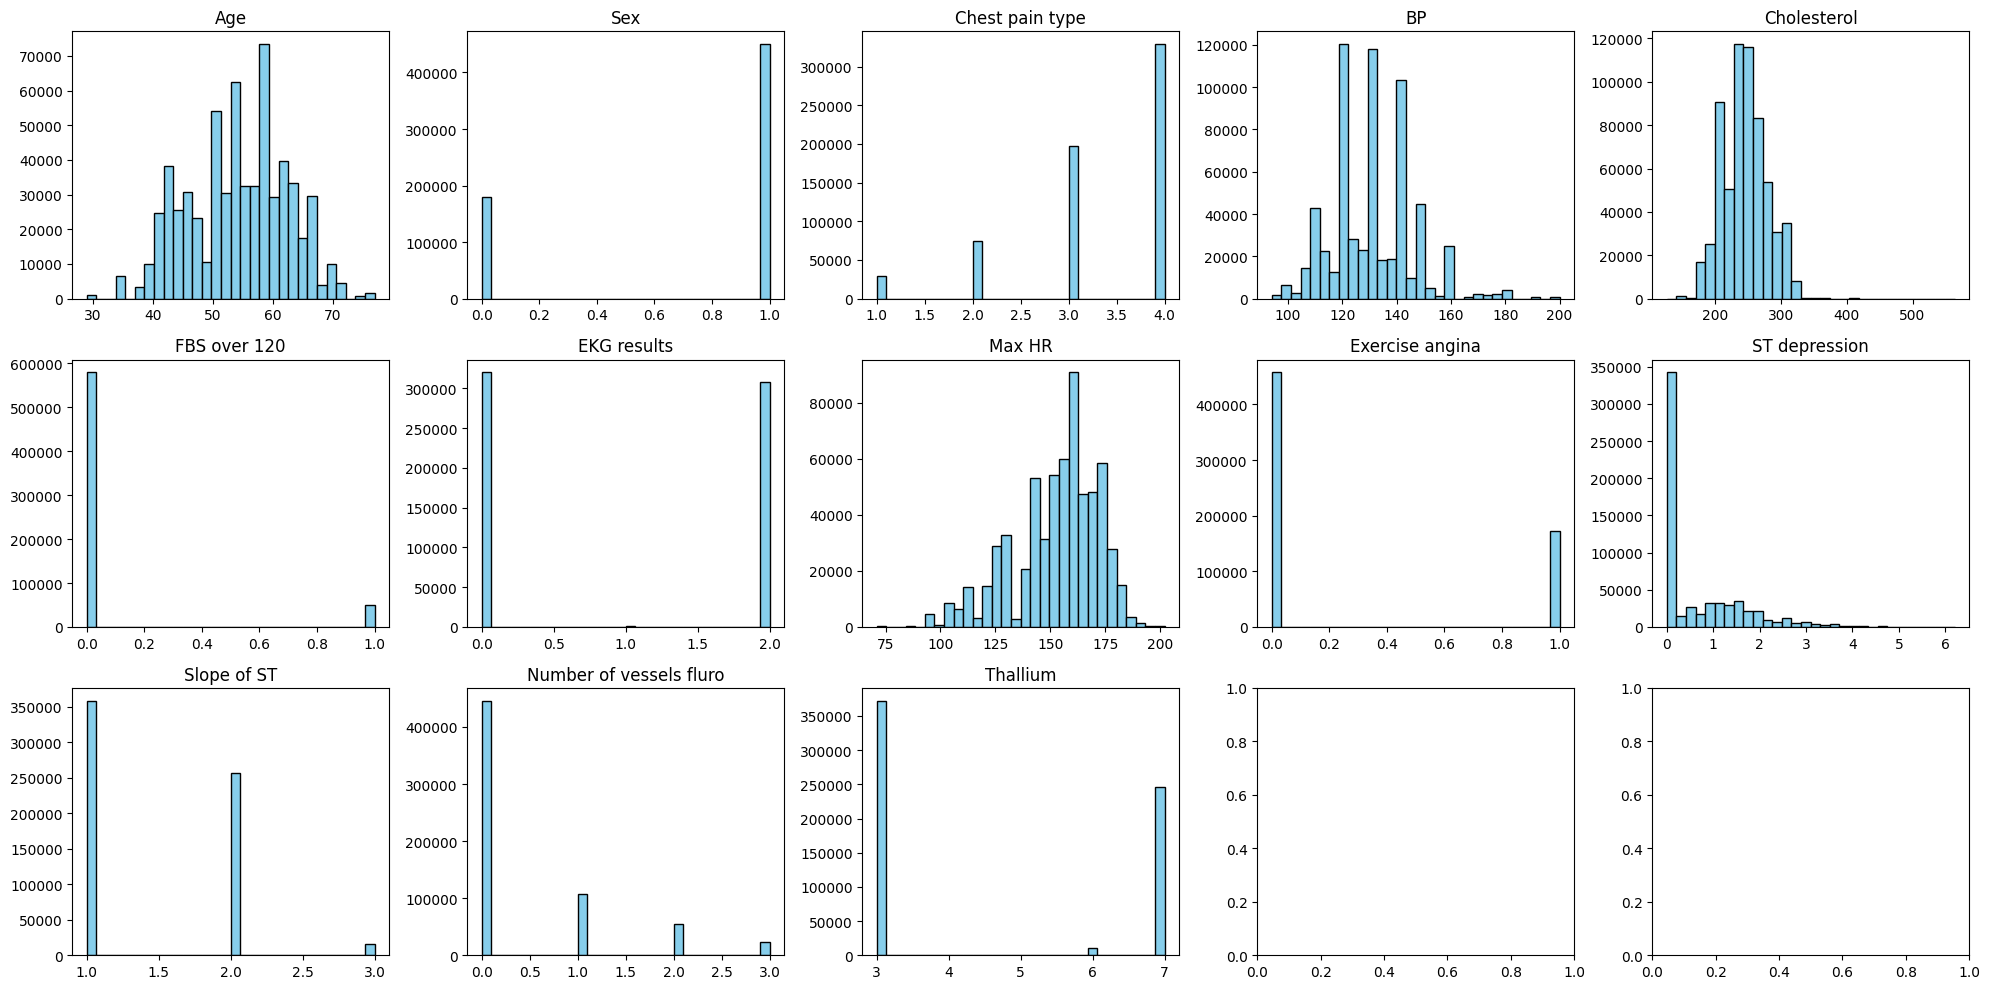

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id']]
total_col = len(numeric_cols)
subplot_x = int(total_col / 5) + 1
subplot_y = 5

fig, axs = plt.subplots(subplot_x, subplot_y, figsize=(20, 10)) # Adjust grid size as needed
axs = axs.flatten() # Flattens the 2D grid to 1D

for i, col in enumerate(numeric_cols):
    if i < len(axs):
        axs[i].hist(train[col], bins=30, color='skyblue', edgecolor='black')
        axs[i].set_title(col)
    else:
        axs[i].axis('off') # Hide unused subplots

plt.tight_layout()
plt.show()

In [7]:
non_numeric_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    print(col," : ",train[col].unique())

Heart Disease  :  ['Presence' 'Absence']


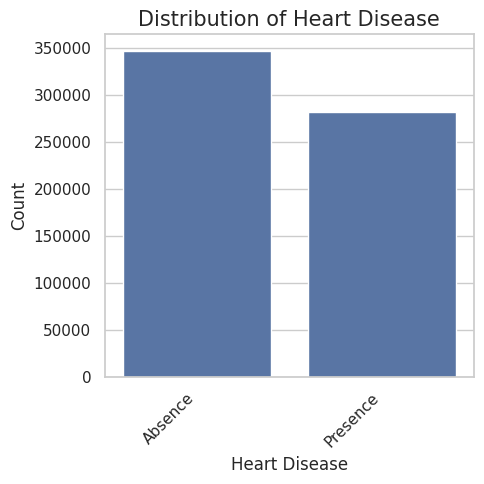

In [8]:
sns.set(style="whitegrid")
#PLOT NON NUMERIC DATA
for col in non_numeric_cols:
    # (width, height)
    plt.figure(figsize=(5, 5))
    
    # order plot with most number to least number data
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    
    # title and x label
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # rotate to avoid x axis on top of each other
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

# Conclusion After Data Visualization

**BP:** 

Problem: Huge number at 120, 130 and 140. This might cause from rounding bias or some other factor.

Solution: We can seperate BP into group like low pressure, normal and high pressure.

**Age:** 

Problem: Most data is about 40~70 years old. And heart disease is highly relate to age.

Solution: We can create a feature is_elder(1: >60 years, 0: <60 years)

**Sex:** 

Problem: Because the huge unbalance this migh cause the prediction bias towards specific gender.

Solution: We can use Stratified K-Fold to make sure the gender ratio is equal in each fold.

# Correlation Map

In [9]:
# transform heart disease data into numerical data
level_mapping = {'Absence': 0, 'Presence': 1}
for col in non_numeric_cols:
    if col in train.columns:
        # ues mapping rule fillna with 0 
        train[col] = train[col].map(level_mapping).fillna(0).astype(int)

In [10]:
train_raw = train.drop(columns=['id'])
train_raw.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


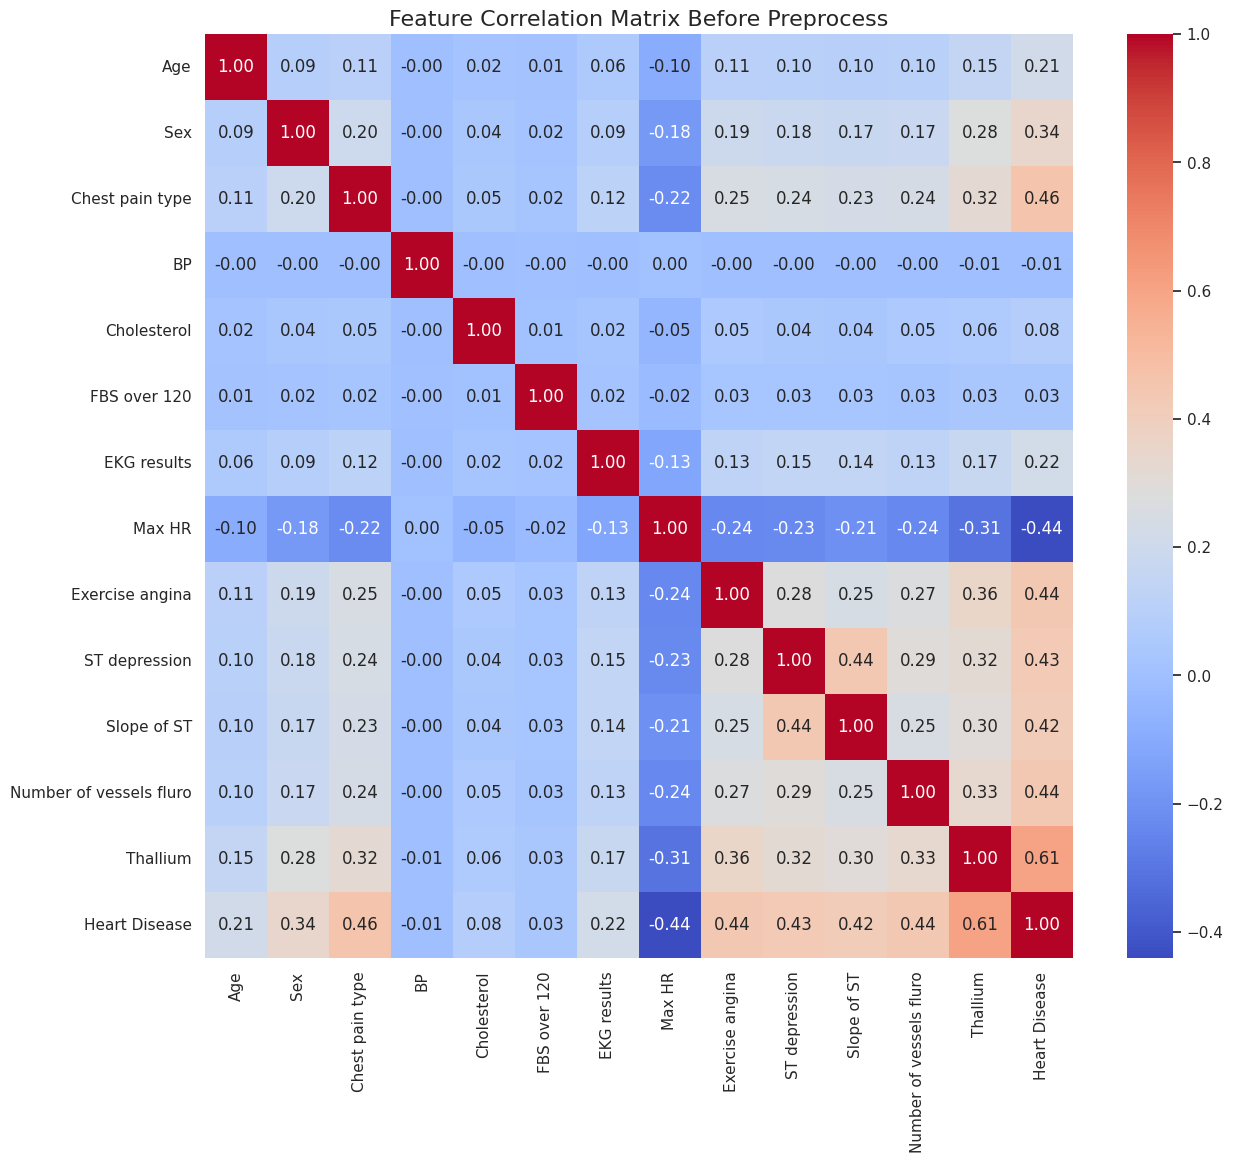

In [11]:
# Check the correlation map before preprocess
# Then compare it with the correlation map of after preprocess 
corr_matrix = train_raw.corr()

# Setup the figure size (make it large enough to read)
plt.figure(figsize=(14, 12))

# Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Matrix Before Preprocess", fontsize=16)
plt.show()

<Axes: xlabel='Heart Disease', ylabel='BP'>

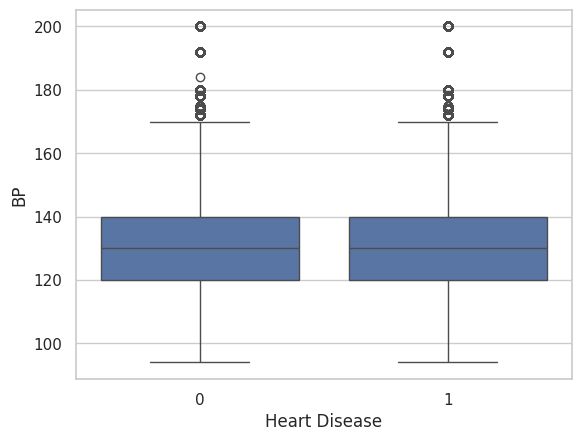

In [12]:
# Check if Heart Disease have some outlier
sns.boxplot(x='Heart Disease', y='BP', data=train_raw)

# Conclusion

**1. Chest pain type(0.46), Thallium(0.61), Slope of ST(0.42), EKG results(0.22):**

These three features(Chest pain type(0.46), Thallium(0.61), Slope of ST(0.42)) are highly correlated with heart disease, but they were originally categorical features.

**Preprocess: Therefore, we may need to use one-hot encoding to avoid confusing the model with the values.**

**2. BP:**

It's strange that blood pressure isn't related to any other characteristic. Yet, according to all medical research, blood pressure is an important feature of heart disease. This could be due to data noise or non-linear correlation.

**Preprocess: (BP_Age_Product = BP * Age) Interact BP with age might lead to some high correlation feature.**


**3. Max HR:**

This feature has a strong correlation with heart disease (-0.44), which is good. However, its value ranges from 70 to 200. This could lead to the model over-relying.

**Preprocess: Standardization**

# Preprocess Data

In [13]:
class Preprocessor:
    def __init__(self):
        self.medians = {}
        self.encoders = {}
        self.numeric_cols = []
        self.all_non_numeric = []
        self.scaler = StandardScaler() # initial std scaler
        self.scaling_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'BP_Age_Product']
        self.categorical_cols = ['Chest pain type', 'Thallium', 'Slope of ST', 'EKG results']
        self.level_mapping = {'Absence': 0, 'Presence': 1}
        self.level_cols = ['Heart Disease']
        
    def fit(self, df):
        """
        Learn the parameters (medians, categories) from the TRAINING data.
        """
        # Identify columns
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        # Learn Medians for numeric columns
        for col in self.numeric_cols:
            self.medians[col] = df[col].median()
            
        # One hot encode the faeture 
        self.one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        self.one_hot_encoder.fit(df[self.categorical_cols].astype(str))

        # StandardScaler
        existing_scaling_cols = [c for c in self.scaling_cols if c in df.columns]
        if existing_scaling_cols:
            self.scaler.fit(df[existing_scaling_cols].fillna(self.medians))
            
        return self

    def transform(self, df):
        """
        Apply the learned parameters to the data (Train or Test).
        """
        df = df.copy()
        
        # Drop irrelevant columns (ID is usually dropped, Target handled separately)
        # Note: We don't drop target here to keep X and y aligned until the end
        if 'id' in df.columns:
            df = df.drop(columns=['id'])

        # level encoding
        for col in self.level_cols:
            if col in df.columns:
                if not np.issubdtype(df[col].dtype, np.number):
                    df[col] = df[col].map(self.level_mapping).fillna(0).astype(int)
                else:
                    df[col] = df[col].fillna(0).astype(int)
        # Impute Missing Values using LEARNED medians
        for col in self.numeric_cols:
            if col in df.columns:
                df[col] = df[col].fillna(self.medians.get(col, 0))

        # Get one hot encode feature
        encoded_array = self.one_hot_encoder.transform(df[self.categorical_cols].astype(str))
        encoded_cols = self.one_hot_encoder.get_feature_names_out(self.categorical_cols)
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
        
        # concat into original df
        df = pd.concat([df, encoded_df], axis=1)
        df = df.drop(columns=self.categorical_cols)

        # StandardScaler
        # make sure Age, BP feature is Standardlize
        target_scaling = [c for c in self.scaling_cols if c in df.columns]
        if target_scaling:
            df[target_scaling] = self.scaler.transform(df[target_scaling])
            
        return df
        
    def create_interaction_features(self, df):# add because of the Correlation matrix
        df = df.copy()
        
        # Age * BP
        if 'Age' in df.columns and 'BP' in df.columns:
            df['BP_Age_Product'] = df['Age'] * df['BP']
        
        return df

In [14]:
train_after.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [15]:
preprocessor = Preprocessor()

train_after_raw = train_after.drop(columns=['id'])

# learn the rule (median value...)
preprocessor.fit(train_after_raw)

# preprocess data
X_train_processed = preprocessor.transform(train_after_raw)

In [16]:
X_train_processed.head()

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Heart Disease,...,Chest pain type_4,Thallium_3,Thallium_6,Thallium_7,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2
0,0.467921,1,1.435822,-0.178490,0,0.271190,1,3.040655,2,1,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-0.258797,1,-0.367088,2.374837,0,0.951359,0,-0.754928,0,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.225682,0,1.970017,-1.692672,0,-0.095054,0,-0.754928,0,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.227755,0,0.233882,-0.475388,0,-0.147375,0,0.299400,0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.467921,1,0.634529,-0.326939,0,-1.455391,1,3.251520,3,1,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [17]:
X_train_processed.columns.tolist()

['Age',
 'Sex',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Number of vessels fluro',
 'Heart Disease',
 'Chest pain type_1',
 'Chest pain type_2',
 'Chest pain type_3',
 'Chest pain type_4',
 'Thallium_3',
 'Thallium_6',
 'Thallium_7',
 'Slope of ST_1',
 'Slope of ST_2',
 'Slope of ST_3',
 'EKG results_0',
 'EKG results_1',
 'EKG results_2']

In [18]:
X_train_interact_feature = preprocessor.create_interaction_features(X_train_processed)
X_train_interact_feature.head()

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Heart Disease,...,Thallium_3,Thallium_6,Thallium_7,Slope of ST_1,Slope of ST_2,Slope of ST_3,EKG results_0,EKG results_1,EKG results_2,BP_Age_Product
0,0.467921,1,1.435822,-0.178490,0,0.271190,1,3.040655,2,1,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.671851
1,-0.258797,1,-0.367088,2.374837,0,0.951359,0,-0.754928,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.095001
2,0.225682,0,1.970017,-1.692672,0,-0.095054,0,-0.754928,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.444597
3,-1.227755,0,0.233882,-0.475388,0,-0.147375,0,0.299400,0,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.287150
4,0.467921,1,0.634529,-0.326939,0,-1.455391,1,3.251520,3,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.296909


In [19]:
X_train_interact_feature.columns.tolist()

['Age',
 'Sex',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Number of vessels fluro',
 'Heart Disease',
 'Chest pain type_1',
 'Chest pain type_2',
 'Chest pain type_3',
 'Chest pain type_4',
 'Thallium_3',
 'Thallium_6',
 'Thallium_7',
 'Slope of ST_1',
 'Slope of ST_2',
 'Slope of ST_3',
 'EKG results_0',
 'EKG results_1',
 'EKG results_2',
 'BP_Age_Product']

# Correlation Map After Preprocess

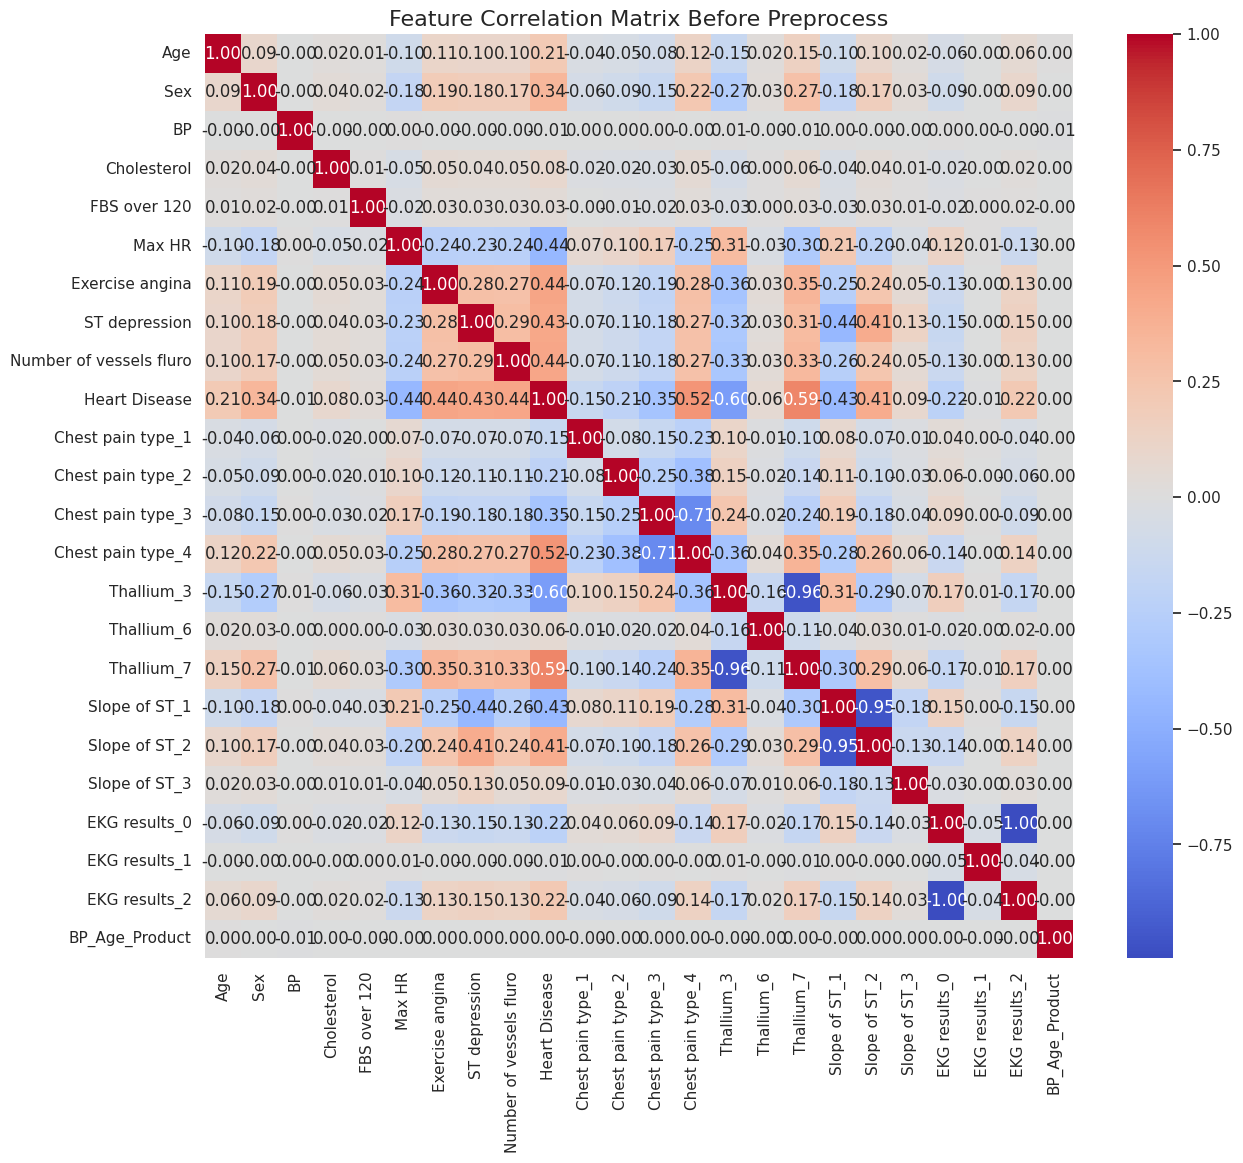

In [20]:
# Check the correlation map after preprocess
# Then compare it with the correlation map of after preprocess 
corr_matrix_after = X_train_interact_feature.corr()

# Setup the figure size (make it large enough to read)
plt.figure(figsize=(14, 12))

# Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(corr_matrix_after, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Matrix Before Preprocess", fontsize=16)
plt.show()